# CC3092 – Deep Learning · Proyecto 2
## Detección secuencial de lavado de dinero en transacciones IBM AML

Este notebook implementa un sistema de detección en dos etapas:

1. **Etapa A:** un LSTM Encoder–Decoder aprende a reconstruir únicamente secuencias normales. El error de reconstrucción se convierte en score de anomalía.
2. **Etapa B:** un clasificador reutiliza el encoder anterior, incorpora atención de producto punto escalado y estima la probabilidad de lavado.

Se incluye una línea base entrenada desde cero, combinación de señales, ablación, interpretabilidad por transacción, cinco casos de prueba y exportación de artefactos para el MVP.

> **Importante:** los resultados y conclusiones numéricas de este notebook se generan al ejecutarlo. No se incluyen métricas finales escritas a mano para evitar inconsistencias entre ejecuciones.


## Bloque 0 — Configuración y reproducibilidad

El modo rápido permite verificar el pipeline. Para la ejecución final se debe usar `MODO_RAPIDO = False`. El notebook está preparado para ejecutarse localmente desde la raíz del proyecto y utiliza rutas relativas, de modo que la carpeta completa pueda moverse o compartirse sin modificar rutas absolutas.

In [1]:
from dataclasses import dataclass, asdict
from pathlib import Path
from collections import Counter
import copy, csv, json, math, os, random, time, warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

@dataclass
class Config:
    SEED: int = 42
    MODO_RAPIDO: bool = False
    DATA_DIR: str = '.'
    IBM_FILE: str = 'ibm-transactions/HI-Small_Trans.csv'
    PATTERNS_FILE: str = 'ibm-transactions/HI-Small_Patterns.txt'
    PAYSIM_FILE: str = 'paysim/PS_20174392719_1491204439457_log.csv'
    ARTIFACT_DIR: str = 'artifacts_aml'
    MIN_SEQ_LEN: int = 3
    MAX_SEQ_LEN: int = 30
    MAX_WINDOWS_PER_SENDER: int = 20
    MAX_NORMAL_AE: int = 60000
    NORMAL_TO_POSITIVE_B: int = 10
    BATCH_SIZE: int = 256
    HIDDEN_SIZE: int = 64
    LATENT_SIZE: int = 64
    ATTN_SIZE: int = 32
    DROPOUT: float = 0.20
    AE_EPOCHS: int = 8
    HEAD_EPOCHS: int = 3
    FINETUNE_EPOCHS: int = 6
    LR_AE: float = 1e-3
    LR_HEAD: float = 1e-3
    LR_ENCODER: float = 1e-4
    PATIENCE: int = 3
    NUM_WORKERS: int = 0

CFG = Config()
if CFG.MODO_RAPIDO:
    CFG.MAX_NORMAL_AE = 8000
    CFG.AE_EPOCHS = 2
    CFG.HEAD_EPOCHS = 1
    CFG.FINETUNE_EPOCHS = 2

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = (PROJECT_ROOT / CFG.DATA_DIR).resolve()
IBM_PATH = DATA_DIR / CFG.IBM_FILE
PATTERNS_PATH = DATA_DIR / CFG.PATTERNS_FILE
PAYSIM_PATH = DATA_DIR / CFG.PAYSIM_FILE
ARTIFACT_DIR = (PROJECT_ROOT / CFG.ARTIFACT_DIR).resolve()
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
T0_GLOBAL = time.time()

print('PyTorch:', torch.__version__)
print('Pandas:', pd.__version__)
print('Dispositivo:', DEVICE)
print('Raíz del proyecto:', PROJECT_ROOT)
print('Archivo IBM:', IBM_PATH)
print('Archivo de patrones:', PATTERNS_PATH)
print('Directorio de artefactos:', ARTIFACT_DIR)
print('Modo rápido:', CFG.MODO_RAPIDO)

PyTorch: 2.14.0+cpu
Pandas: 2.3.3
Dispositivo: cpu
Raíz del proyecto: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2
Archivo IBM: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2\ibm-transactions\HI-Small_Trans.csv
Archivo de patrones: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2\ibm-transactions\HI-Small_Patterns.txt
Directorio de artefactos: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2\artifacts_aml
Modo rápido: False


## Bloque 1 — Decisión de dataset

En nuestra exploración del dataset encontramos que PaySim tiene 6,353,307 remitentes, pero 99 % de ellos posee una sola transacción. Solo 28 remitentes fraudulentos tienen dos transacciones y ninguno tiene tres. Por ello, PaySim no permite aprender comportamiento histórico real por remitente.

IBM AML sí contiene historiales: HI-Small tiene 496,999 remitentes, 3,376 remitentes positivos y percentil 90 de longitud igual a 29. Se selecciona HI-Small porque es menor que LI-Small y ofrece más casos positivos, aunque conserva un desbalance fuerte.

In [2]:
paysim_audit = pd.Series({
    'transacciones': 6_362_620, 'remitentes': 6_353_307,
    'remitentes_longitud_2_o_mas': 9_298,
    'remitentes_longitud_3_o_mas': 15,
    'remitentes_fraudulentos': 8_213,
    'fraudulentos_longitud_2_o_mas': 28,
    'fraudulentos_longitud_3_o_mas': 0
}, name='PaySim — auditoría ejecutada por el grupo')

ibm_comparison = pd.DataFrame({
    'HI-Small': [5_078_345, 5_177, 496_999, 3_376, 0.00679277, 2, 46, 92],
    'LI-Small': [6_924_049, 3_565, 681_283, 2_382, 0.00349634, 2, 46, 92]
}, index=['transacciones','transacciones_positivas','remitentes','remitentes_positivos',
          'tasa_remitentes_positivos','mediana_longitud','p95_longitud','p99_longitud'])

display(paysim_audit.to_frame())
display(ibm_comparison)
assert paysim_audit['fraudulentos_longitud_3_o_mas'] == 0
assert ibm_comparison.loc['remitentes_positivos','HI-Small'] > ibm_comparison.loc['remitentes_positivos','LI-Small']
print('Decisión documentada: HI-Small será el dataset secuencial principal.')

,PaySim — auditoría ejecutada por el grupo
transacciones,6362620
remitentes,6353307
remitentes_longitud_2_o_mas,9298
remitentes_longitud_3_o_mas,15
remitentes_fraudulentos,8213
fraudulentos_longitud_2_o_mas,28
fraudulentos_longitud_3_o_mas,0


,HI-Small,LI-Small
transacciones,5.078345e+06,6.924049e+06
transacciones_positivas,5.177000e+03,3.565000e+03
remitentes,4.969990e+05,6.812830e+05
remitentes_positivos,3.376000e+03,2.382000e+03
tasa_remitentes_positivos,6.792770e-03,3.496340e-03
mediana_longitud,2.000000e+00,2.000000e+00
p95_longitud,4.600000e+01,4.600000e+01
p99_longitud,9.200000e+01,9.200000e+01


Decisión documentada: HI-Small será el dataset secuencial principal.


### Justificación de la selección del dataset

Aunque PaySim se consideró inicialmente como dataset principal, el análisis de su estructura mostró una limitación importante para este proyecto: 6,353,307 de sus remitentes corresponden a una población en la que aproximadamente el 99 % presenta una sola transacción. Entre los 8,213 remitentes asociados con fraude, únicamente 28 poseen al menos dos transacciones y ninguno alcanza tres. Por tanto, construir secuencias históricas por remitente requeriría crear artificialmente una estructura temporal que los datos no contienen.

En contraste, IBM AML HI-Small contiene 5,078,345 transacciones correspondientes a 496,999 remitentes, de los cuales 3,376 presentan al menos una transacción etiquetada como lavado. La mediana del historial es de 2 transacciones, el percentil 90 es 29 y el percentil 95 es 46. Esta estructura permite estudiar comportamiento secuencial real dentro del dataset.

Por esta razón se seleccionó **IBM AML HI-Small como dataset principal para el modelado secuencial**. La decisión no se basa únicamente en tamaño, sino en la compatibilidad entre la estructura de los datos y el objetivo del proyecto: aprender patrones temporales de comportamiento por remitente. PaySim se conserva como referencia comparativa para justificar esta decisión.

## Bloque 2 — Carga y auditoría de HI-Small

El remitente se identifica con la clave compuesta `(From Bank, Account)`, ya que un número de cuenta aislado no representa necesariamente una identidad global. La etiqueta nunca se usa como feature.

In [3]:
assert IBM_PATH.exists(), f'No se encontró {IBM_PATH}. Ajuste CFG.DATA_DIR.'

DTYPES = {
    'From Bank':'int32', 'Account':'string', 'To Bank':'int32', 'Account.1':'string',
    'Amount Received':'float32', 'Receiving Currency':'category',
    'Amount Paid':'float32', 'Payment Currency':'category',
    'Payment Format':'category', 'Is Laundering':'int8'
}

t0 = time.time()
df = pd.read_csv(IBM_PATH, dtype=DTYPES)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M', errors='coerce')
df['sender_id'] = df['From Bank'].astype(str) + '::' + df['Account'].astype(str)
df['dest_id'] = df['To Bank'].astype(str) + '::' + df['Account.1'].astype(str)

print(f'Filas: {len(df):,} | Columnas: {df.shape[1]} | Carga: {time.time()-t0:.1f}s')
print('Periodo:', df['Timestamp'].min(), '—', df['Timestamp'].max())
print('Valores faltantes:', int(df.isna().sum().sum()))
print('Duplicados:', int(df.duplicated().sum()))
print('Proporción de transacciones positivas:', f"{df['Is Laundering'].mean():.6%}")
display(df.head())

assert df['Timestamp'].notna().all(), 'Existen timestamps inválidos.'
assert set(df['Is Laundering'].unique()).issubset({0,1})

Filas: 5,078,345 | Columnas: 13 | Carga: 7.0s
Periodo: 2022-09-01 00:00:00 — 2022-09-18 16:18:00
Valores faltantes: 0
Duplicados: 9
Proporción de transacciones positivas: 0.101943%


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,sender_id,dest_id
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.340088,US Dollar,3697.340088,US Dollar,Reinvestment,0,10::8000EBD30,10::8000EBD30
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0,3208::8000F4580,1::8000F5340
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.570312,US Dollar,14675.570312,US Dollar,Reinvestment,0,3209::8000F4670,3209::8000F4670
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.969971,US Dollar,2806.969971,US Dollar,Reinvestment,0,12::8000F5030,12::8000F5030
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.968750,US Dollar,36682.968750,US Dollar,Reinvestment,0,10::8000F5200,10::8000F5200


### Análisis de calidad de datos

HI-Small contiene **5,078,345 transacciones** y cubre el periodo comprendido entre el **1 y el 18 de septiembre de 2022**. No se detectaron valores faltantes y todos los timestamps pudieron interpretarse correctamente. Se identificaron únicamente **9 filas duplicadas**, una cantidad despreciable frente al tamaño total del dataset, aunque su existencia se documenta como parte de la auditoría de calidad.

La proporción de transacciones etiquetadas como lavado es de aproximadamente **0.102 %**, lo que confirma un desbalance extremo a nivel transaccional. Este resultado desaconseja utilizar accuracy como métrica principal: un modelo que favorezca sistemáticamente la clase normal podría obtener una accuracy elevada sin proporcionar utilidad real para detectar actividad sospechosa.

La identidad del remitente se define mediante la combinación `(From Bank, Account)`, evitando asumir que un número de cuenta aislado identifica globalmente a un cliente. De manera equivalente, el destino se representa mediante `(To Bank, Account.1)`. Estos identificadores se conservan para agrupación y trazabilidad, pero no se utilizan directamente como variables predictoras.

count    496999.000000
mean         10.218019
std         290.282946
min           1.000000
50%           2.000000
75%           5.000000
90%          29.000000
95%          46.000000
99%          92.000000
max      168672.000000
Name: n_transactions, dtype: float64


Remitentes positivos: 3376
Remitentes con 3 o más: 185993


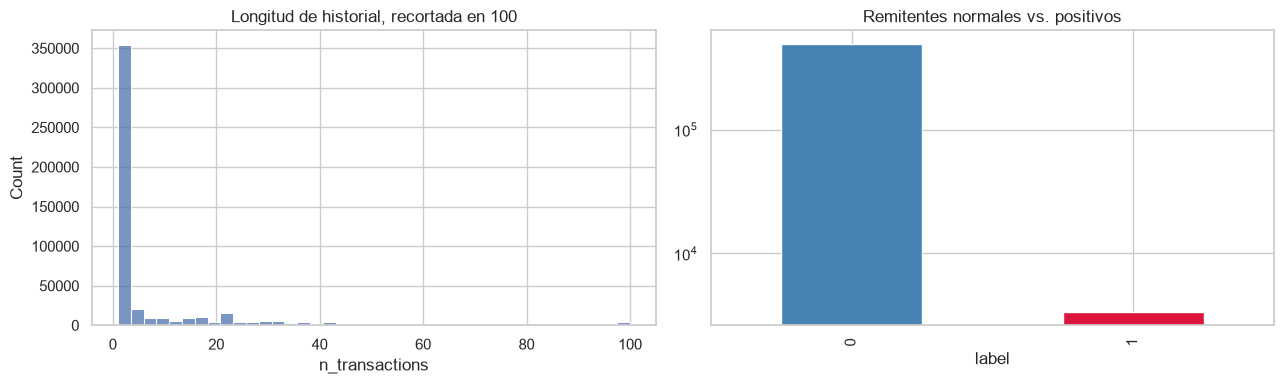

In [4]:
sender_audit = df.groupby('sender_id', observed=True).agg(
    n_transactions=('Is Laundering','size'),
    label=('Is Laundering','max')
)

display(sender_audit['n_transactions'].describe(percentiles=[.5,.75,.9,.95,.99]))
print()
print('Remitentes positivos:', int(sender_audit['label'].sum()))
print('Remitentes con 3 o más:', int((sender_audit['n_transactions'] >= 3).sum()))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(sender_audit['n_transactions'].clip(upper=100), bins=40, ax=axes[0])
axes[0].set_title('Longitud de historial, recortada en 100')
sender_audit['label'].value_counts().sort_index().plot.bar(ax=axes[1], color=['steelblue','crimson'])
axes[1].set_title('Remitentes normales vs. positivos'); axes[1].set_yscale('log')
plt.tight_layout(); plt.show()

## Bloque 3 — Split por remitente

El split se realiza antes de construir ventanas. Así, todas las transacciones de una misma cuenta quedan en un único conjunto y se evita filtración de comportamiento entre entrenamiento, validación y prueba.

In [5]:
eligible = sender_audit.query('n_transactions >= @CFG.MIN_SEQ_LEN').reset_index()

train_s, temp_s = train_test_split(
    eligible, test_size=0.30, random_state=CFG.SEED, stratify=eligible['label'])
val_s, test_s = train_test_split(
    temp_s, test_size=0.50, random_state=CFG.SEED, stratify=temp_s['label'])

split_map = {**dict(zip(train_s.sender_id, ['train']*len(train_s))),
             **dict(zip(val_s.sender_id, ['val']*len(val_s))),
             **dict(zip(test_s.sender_id, ['test']*len(test_s)))}

for name, part in [('train',train_s),('val',val_s),('test',test_s)]:
    print(name, f'remitentes={len(part):,}', f'positivos={int(part.label.sum()):,}',
          f'tasa={part.label.mean():.4%}')

assert set(train_s.sender_id).isdisjoint(val_s.sender_id)
assert set(train_s.sender_id).isdisjoint(test_s.sender_id)
assert set(val_s.sender_id).isdisjoint(test_s.sender_id)

train remitentes=130,195 positivos=1,931 tasa=1.4832%
val remitentes=27,899 positivos=414 tasa=1.4839%
test remitentes=27,899 positivos=413 tasa=1.4803%


### Análisis de la separación de datos

La separación se realizó a nivel de **remitente y antes de construir las ventanas temporales**. Esta decisión es fundamental para evitar filtración: todas las transacciones y todas las ventanas pertenecientes a un mismo remitente permanecen exclusivamente en entrenamiento, validación o prueba.

Se obtuvieron **130,195 remitentes de entrenamiento**, **27,899 de validación** y **27,899 de prueba**. Las tasas de remitentes positivos fueron respectivamente **1.4832 %, 1.4839 % y 1.4803 %**, mostrando que la estratificación conservó prácticamente la misma prevalencia en los tres conjuntos.

El conjunto de validación se utiliza para seleccionar umbrales, pesos de combinación y estados del modelo. El conjunto de prueba permanece fuera de estas decisiones y se utiliza únicamente para la evaluación final. Esto reduce el riesgo de obtener métricas optimistas debido a decisiones ajustadas indirectamente sobre test.

Se optó por una separación estratificada por remitente en lugar de una separación puramente temporal porque el objetivo principal de esta demostración es evaluar generalización hacia remitentes no observados. Una validación temporal constituiría un experimento adicional útil para estudiar deriva temporal, pero no sustituye la necesidad de impedir que un mismo remitente aparezca en varios splits.

## Bloque 4 — Features causales y secuencias

Las variables derivadas usan únicamente la transacción actual y el pasado del mismo remitente. Los identificadores de cuenta no entran al modelo: se conservan solo para trazabilidad.

Las ventanas tienen máximo 30 transacciones, aproximadamente el percentil 90 observado. Para impedir que cuentas gigantes dominen el experimento, se conservan como máximo 20 ventanas por remitente mediante selección uniforme e independiente de la etiqueta.

In [6]:
df = df[df['sender_id'].isin(split_map)].copy()
df['split'] = df['sender_id'].map(split_map)
df.sort_values(['sender_id','Timestamp'], inplace=True, kind='mergesort')
df.reset_index(drop=False, inplace=True)
df.rename(columns={'index':'original_row'}, inplace=True)

g = df.groupby('sender_id', observed=True, sort=False)
df['delta_minutes'] = g['Timestamp'].diff().dt.total_seconds().div(60).fillna(0).clip(lower=0)
df['sender_position'] = g.cumcount()
df['sender_count'] = g['sender_id'].transform('size')
df['position_ratio'] = df['sender_position'] / (df['sender_count']-1).clip(lower=1)
df['destination_changed'] = df['dest_id'].ne(g['dest_id'].shift()).astype('int8')
df.loc[df['sender_position'].eq(0), 'destination_changed'] = 0
df['new_destination'] = (~df.duplicated(['sender_id','dest_id'])).astype('int8')
df['same_bank'] = (df['From Bank'] == df['To Bank']).astype('int8')
df['same_account'] = (df['sender_id'] == df['dest_id']).astype('int8')
df['currency_changed'] = (df['Payment Currency'].astype(str) != df['Receiving Currency'].astype(str)).astype('int8')
df['log_amount_paid'] = np.log1p(df['Amount Paid'].clip(lower=0))
df['log_amount_received'] = np.log1p(df['Amount Received'].clip(lower=0))
df['log_amount_gap'] = np.log1p((df['Amount Paid']-df['Amount Received']).abs())
df['log_fx_ratio'] = np.log((df['Amount Received']+1e-6)/(df['Amount Paid']+1e-6)).clip(-10,10)
df['log_delta_minutes'] = np.log1p(df['delta_minutes'])
df['log_tx_count_so_far'] = np.log1p(df['sender_position']+1)
df['hour_sin'] = np.sin(2*np.pi*df['Timestamp'].dt.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df['Timestamp'].dt.hour/24)
df['day_offset'] = (df['Timestamp']-df['Timestamp'].min()).dt.total_seconds()/86400

CONT_COLS = ['log_amount_paid','log_amount_received','log_amount_gap','log_fx_ratio',
             'log_delta_minutes','log_tx_count_so_far','hour_sin','hour_cos',
             'day_offset','position_ratio','same_bank','same_account',
             'currency_changed','destination_changed','new_destination']
CAT_COLS = ['Payment Currency','Receiving Currency','Payment Format']

def make_windows(frame):
    records = []
    labels = frame['Is Laundering'].to_numpy()
    splits = frame['split'].to_numpy()
    for sender, part in frame.groupby('sender_id', observed=True, sort=False):
        start0, n = part.index[0], len(part)
        candidate = []
        for offset in range(0, n, CFG.MAX_SEQ_LEN):
            end = min(offset + CFG.MAX_SEQ_LEN, n)
            if end-offset >= CFG.MIN_SEQ_LEN:
                s, e = start0+offset, start0+end
                candidate.append((s,e))
        if len(candidate) > CFG.MAX_WINDOWS_PER_SENDER:
            chosen = np.linspace(0, len(candidate)-1, CFG.MAX_WINDOWS_PER_SENDER).round().astype(int)
            candidate = [candidate[i] for i in np.unique(chosen)]
        for s,e in candidate:
            records.append({
                'sender_id': sender, 'split': splits[s], 'start':s, 'end':e,
                'length':e-s, 'label':int(labels[s:e].max())
            })
    return pd.DataFrame(records)

windows = make_windows(df)
display(windows.groupby('split').agg(windows=('label','size'), positives=('label','sum'),
                                     rate=('label','mean'), mean_length=('length','mean')))
assert windows['length'].between(CFG.MIN_SEQ_LEN, CFG.MAX_SEQ_LEN).all()

,windows,positives,rate,mean_length
split,,,,
test,37778,424,0.011223,16.783260
train,174659,1953,0.011182,16.662147
val,37162,419,0.011275,16.549055


### Justificación de la representación secuencial

Cada secuencia representa un fragmento cronológicamente ordenado del comportamiento de un único remitente. Se utiliza una longitud mínima de **3 transacciones**, ya que historiales más cortos ofrecen muy poca información temporal para caracterizar cambios de frecuencia, destino o comportamiento. La longitud máxima se fija en **30 transacciones**, aproximadamente el percentil 90 de longitud observado en HI-Small. Los historiales más largos se dividen en ventanas y se limita el número de ventanas por remitente para evitar que unas pocas cuentas extremadamente activas dominen el entrenamiento.

Las variables fueron seleccionadas para representar diferentes dimensiones del comportamiento transaccional:

- Los montos transformados mediante `log1p` reducen el efecto de distribuciones fuertemente asimétricas y permiten representar diferencias relativas entre operaciones pequeñas y grandes.
- `delta_minutes` y el conteo acumulado representan **frecuencia y velocidad transaccional**, relevantes para detectar incrementos abruptos de actividad.
- Las variables de hora mediante seno y coseno conservan la naturaleza cíclica del tiempo y permiten representar actividad en horarios inusuales.
- `destination_changed` y `new_destination` capturan cambios de contraparte y aparición de nuevos destinos, comportamientos potencialmente relevantes para patrones de dispersión.
- `same_bank`, `same_account` y `currency_changed` describen características estructurales de la transferencia.
- La diferencia entre montos enviados y recibidos y el ratio asociado permiten representar transformaciones de valor y moneda.
- Las variables categóricas de moneda y formato de pago se codifican mediante one-hot encoding.

Todas las variables derivadas utilizan únicamente información disponible en la transacción actual o en el pasado del remitente. No se utiliza la etiqueta para construir features. El escalador y el codificador categórico se ajustan exclusivamente con datos de entrenamiento.

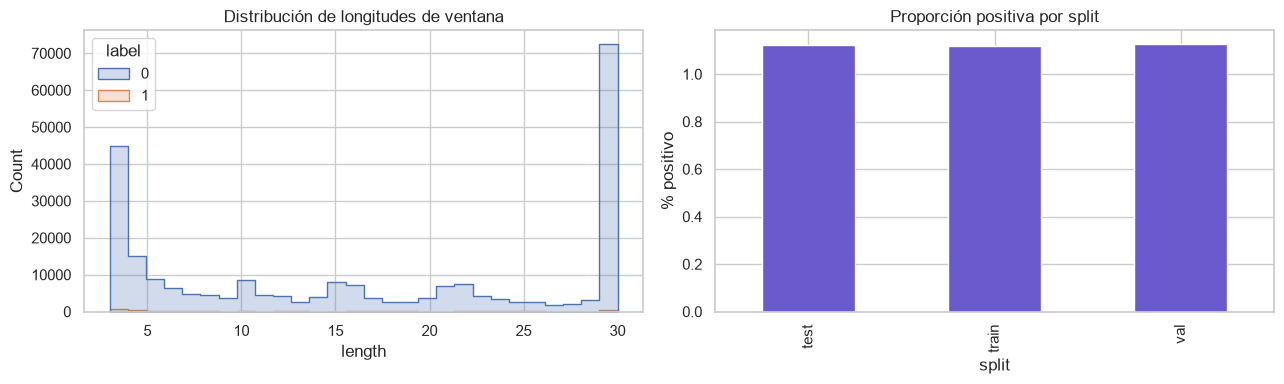

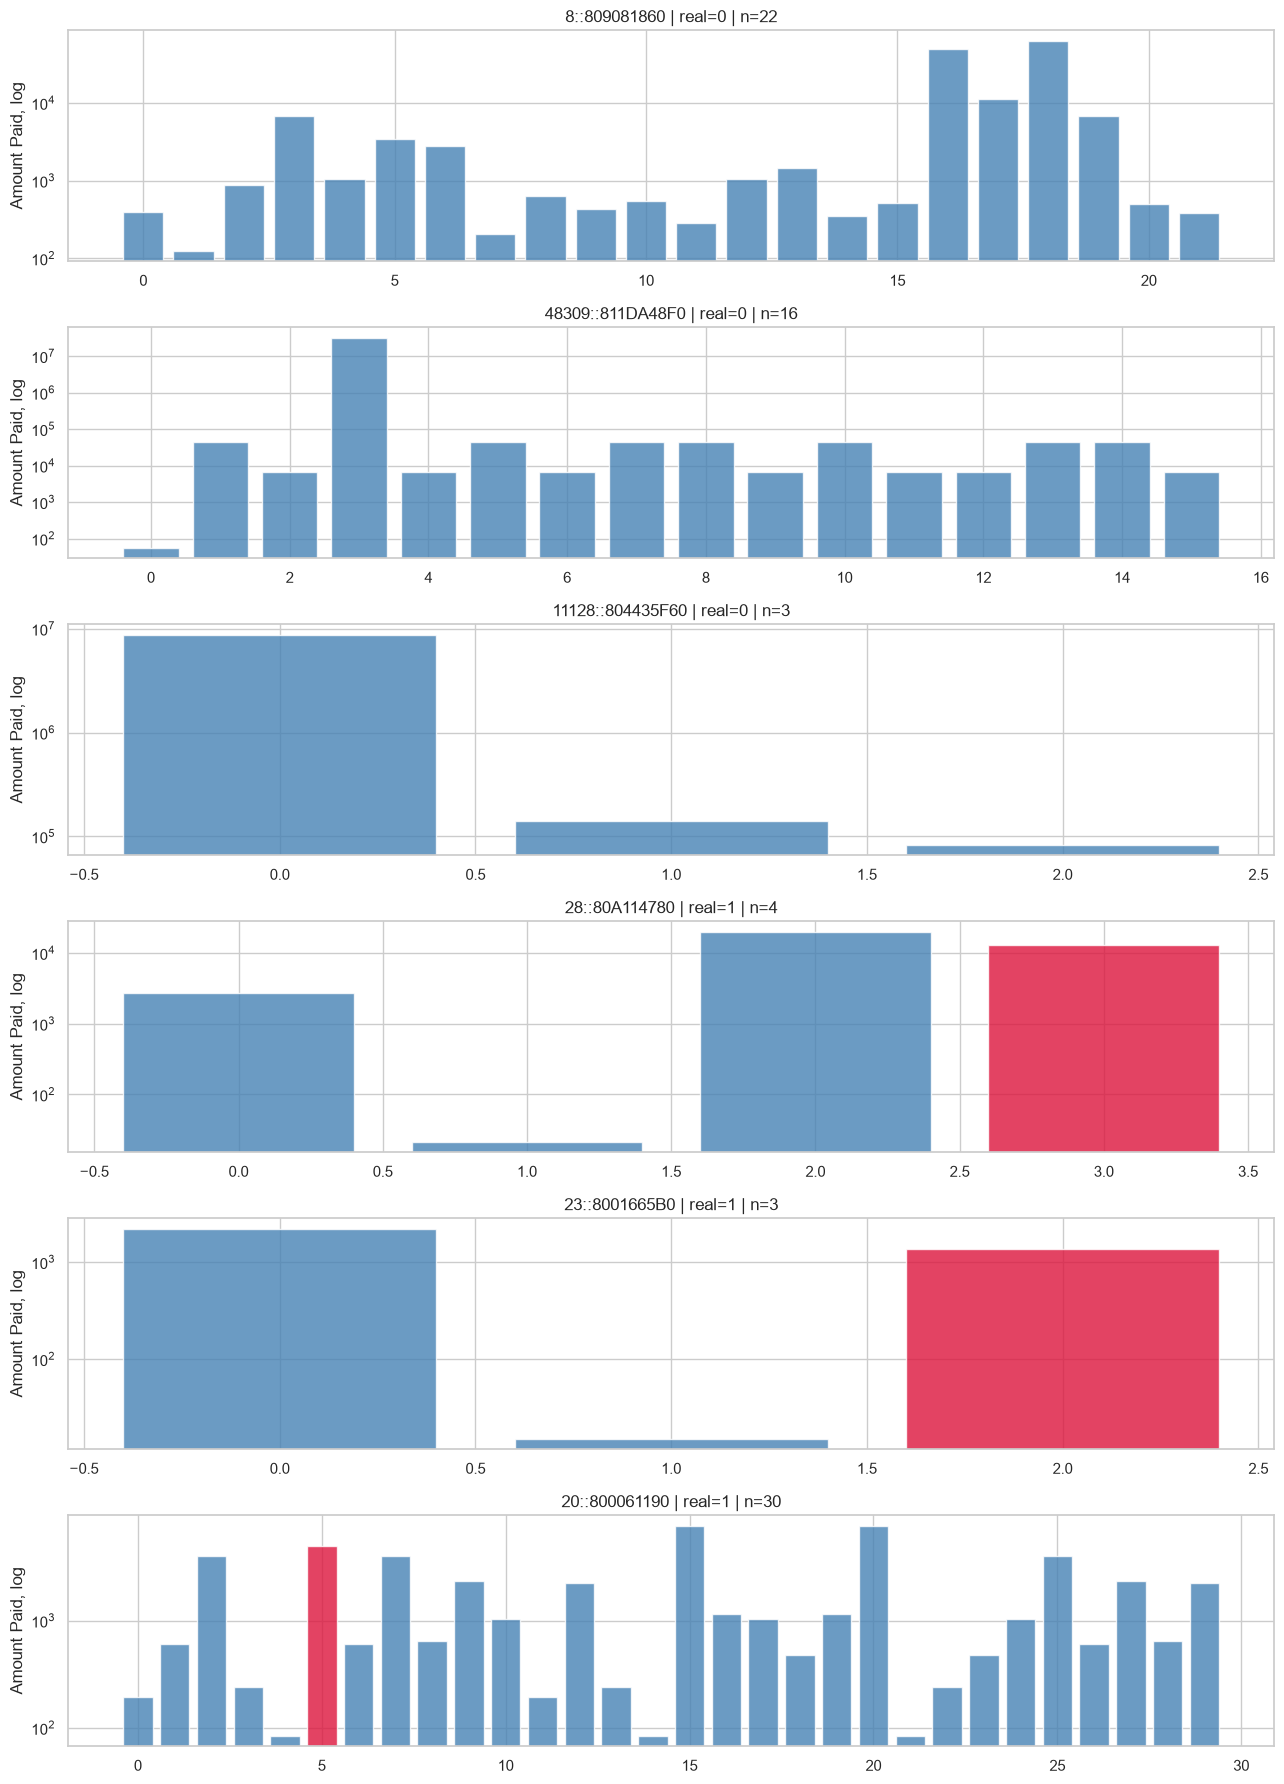

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(data=windows, x='length', hue='label', bins=28, element='step', ax=axes[0])
axes[0].set_title('Distribución de longitudes de ventana')
windows.groupby('split')['label'].mean().mul(100).plot.bar(ax=axes[1], color='slateblue')
axes[1].set_ylabel('% positivo'); axes[1].set_title('Proporción positiva por split')
plt.tight_layout(); plt.show()

def plot_sequence_examples(frame, meta, n_each=3):
    selected = pd.concat([
        meta.query('split == "train" and label == 0').sample(n_each, random_state=CFG.SEED),
        meta.query('split == "train" and label == 1').sample(n_each, random_state=CFG.SEED)
    ])
    fig, axes = plt.subplots(len(selected), 1, figsize=(13, 3*len(selected)), squeeze=False)
    for ax, (_, w) in zip(axes[:,0], selected.iterrows()):
        p = frame.iloc[int(w.start):int(w.end)]
        colors = np.where(p['Is Laundering'].to_numpy()==1, 'crimson', 'steelblue')
        ax.bar(range(len(p)), p['Amount Paid'], color=colors, alpha=.8)
        ax.set_yscale('log'); ax.set_ylabel('Amount Paid, log')
        ax.set_title(f"{w.sender_id} | real={w.label} | n={w.length}")
    plt.tight_layout(); plt.show()

plot_sequence_examples(df, windows, n_each=3)

## Bloque 5 — Preprocesamiento sin filtración

El escalador y el one-hot encoder se ajustan exclusivamente con filas pertenecientes a ventanas de entrenamiento. Después se transforman validación y prueba con los mismos parámetros.

In [8]:
def select_training_windows(meta):
    train = meta.query('split == "train"')
    pos = train.query('label == 1')
    neg = train.query('label == 0')
    max_neg = min(len(neg), max(CFG.MAX_NORMAL_AE, CFG.NORMAL_TO_POSITIVE_B*max(len(pos),1)))
    neg = neg.sample(max_neg, random_state=CFG.SEED)
    return pd.concat([pos,neg]).sample(frac=1, random_state=CFG.SEED).reset_index(drop=True)

train_windows = select_training_windows(windows)
val_windows = windows.query('split == "val"').reset_index(drop=True)
test_windows = windows.query('split == "test"').reset_index(drop=True)
selected_windows = pd.concat([train_windows,val_windows,test_windows], ignore_index=True)

used = np.zeros(len(df), dtype=bool)
for w in selected_windows.itertuples(): used[w.start:w.end] = True
old_to_new = np.full(len(df), -1, dtype=np.int64)
old_to_new[np.flatnonzero(used)] = np.arange(used.sum())
compact = df.loc[used].copy().reset_index(drop=True)

for meta in (train_windows,val_windows,test_windows):
    meta['start_compact'] = meta['start'].map(lambda x: int(old_to_new[int(x)]))
    meta['end_compact'] = meta['end'].map(lambda x: int(old_to_new[int(x)-1])+1)

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False, dtype=np.float32)

preprocessor = ColumnTransformer([
    ('continuous', StandardScaler(), CONT_COLS),
    ('categorical', ohe, CAT_COLS)
], remainder='drop', verbose_feature_names_out=False)

train_row_mask = compact['split'].eq('train')
preprocessor.fit(compact.loc[train_row_mask, CONT_COLS+CAT_COLS])
X_all = preprocessor.transform(compact[CONT_COLS+CAT_COLS]).astype('float32')
FEATURE_NAMES = list(preprocessor.get_feature_names_out())

print('Filas utilizadas:', f'{len(compact):,}', '| Features:', X_all.shape[1])
print(FEATURE_NAMES)
assert np.isfinite(X_all).all()

Filas utilizadas: 2,270,514 | Features: 52
['log_amount_paid', 'log_amount_received', 'log_amount_gap', 'log_fx_ratio', 'log_delta_minutes', 'log_tx_count_so_far', 'hour_sin', 'hour_cos', 'day_offset', 'position_ratio', 'same_bank', 'same_account', 'currency_changed', 'destination_changed', 'new_destination', 'Payment Currency_Australian Dollar', 'Payment Currency_Bitcoin', 'Payment Currency_Brazil Real', 'Payment Currency_Canadian Dollar', 'Payment Currency_Euro', 'Payment Currency_Mexican Peso', 'Payment Currency_Ruble', 'Payment Currency_Rupee', 'Payment Currency_Saudi Riyal', 'Payment Currency_Shekel', 'Payment Currency_Swiss Franc', 'Payment Currency_UK Pound', 'Payment Currency_US Dollar', 'Payment Currency_Yen', 'Payment Currency_Yuan', 'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Cur

## Bloque 6 — Dataset, padding y máscaras

Cada ejemplo devuelve la secuencia, longitud, etiqueta e índice de ventana. El padding se crea en `collate_fn`; la máscara garantiza que las posiciones artificiales no afecten la pérdida ni la atención.

In [9]:
class SequenceDataset(Dataset):
    def __init__(self, features, metadata):
        self.X = features; self.meta = metadata.reset_index(drop=True)
    def __len__(self): return len(self.meta)
    def __getitem__(self, i):
        w = self.meta.iloc[i]
        x = torch.from_numpy(self.X[int(w.start_compact):int(w.end_compact)])
        return x, int(w.label), i

def collate_sequences(batch):
    xs, ys, ids = zip(*batch)
    lengths = torch.tensor([len(x) for x in xs], dtype=torch.long)
    padded = torch.zeros(len(xs), int(lengths.max()), xs[0].shape[1])
    mask = torch.zeros(len(xs), int(lengths.max()), dtype=torch.bool)
    for i,x in enumerate(xs):
        padded[i,:len(x)] = x; mask[i,:len(x)] = True
    return padded, lengths, mask, torch.tensor(ys, dtype=torch.float32), torch.tensor(ids)

def make_loader(meta, shuffle=False, batch_size=None):
    ds = SequenceDataset(X_all, meta)
    return DataLoader(ds, batch_size=batch_size or CFG.BATCH_SIZE, shuffle=shuffle,
                      num_workers=CFG.NUM_WORKERS, collate_fn=collate_sequences,
                      pin_memory=torch.cuda.is_available())

ae_train_meta = train_windows.query('label == 0')
if len(ae_train_meta) > CFG.MAX_NORMAL_AE:
    ae_train_meta = ae_train_meta.sample(CFG.MAX_NORMAL_AE, random_state=CFG.SEED)
ae_val_meta = val_windows.query('label == 0')

ae_train_loader = make_loader(ae_train_meta, shuffle=True)
ae_val_loader = make_loader(ae_val_meta)
train_loader = make_loader(train_windows, shuffle=True)
val_loader = make_loader(val_windows)
test_loader = make_loader(test_windows)

xb, lb, mb, yb, ib = next(iter(train_loader))
print('X:', xb.shape, 'longitudes:', lb.shape, 'máscara:', mb.shape, 'y:', yb.shape)
assert torch.equal(mb.sum(1), lb)
assert xb.shape[2] == len(FEATURE_NAMES)

X: torch.Size([256, 30, 52]) longitudes: torch.Size([256]) máscara: torch.Size([256, 30]) y: torch.Size([256])


### Manejo del desbalance y secuencias de longitud variable

El fuerte desbalance observado requiere evitar que la clase normal domine el aprendizaje supervisado. Para entrenamiento se limita el número de ventanas negativas utilizadas, manteniendo todos los ejemplos positivos disponibles. Esta selección se aplica exclusivamente al conjunto de entrenamiento; validación y prueba conservan su distribución original para que las métricas representen un escenario de evaluación no balanceado artificialmente.

En la Etapa B se utiliza adicionalmente `BCEWithLogitsLoss` con `pos_weight`, calculado a partir de la relación entre negativos y positivos del conjunto de entrenamiento. De esta manera, los errores sobre la clase minoritaria reciben mayor peso durante la optimización. Esta estrategia busca aumentar la capacidad de detectar casos sospechosos sin modificar artificialmente la prevalencia de validación y prueba.

Las secuencias poseen longitudes diferentes, por lo que cada batch utiliza padding hasta la longitud máxima presente en él. Una máscara booleana distingue transacciones reales de posiciones artificiales. El encoder utiliza `pack_padded_sequence`, la pérdida de reconstrucción excluye el padding y el mecanismo de atención asigna peso prácticamente nulo a posiciones enmascaradas. Las verificaciones automáticas al final del notebook comprueban estas propiedades.

## Bloque 7 — Etapa A: LSTM Encoder–Decoder

El encoder comprime la secuencia en su último estado válido. El decoder recibe esa representación en cada paso e intenta reconstruir la secuencia completa. El MSE se calcula únicamente sobre posiciones reales.

In [10]:
class SequenceEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h,c) = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))
        return self.dropout(out), h[-1], c[-1]

class LSTMSequenceAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size, dropout):
        super().__init__()
        self.encoder = SequenceEncoder(input_size, hidden_size, dropout)
        self.to_latent = nn.Linear(hidden_size, latent_size)
        self.decoder = nn.LSTM(latent_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, input_size)
    def forward(self, x, lengths):
        enc_out, h_last, _ = self.encoder(x, lengths)
        z = torch.tanh(self.to_latent(h_last))
        dec_in = z.unsqueeze(1).expand(-1, x.size(1), -1)
        dec_out, _ = self.decoder(dec_in)
        return self.output(dec_out), z, enc_out

def reconstruction_errors(x, recon, mask):
    per_feature = (x-recon).pow(2)
    per_tx = per_feature.mean(-1)
    per_tx = per_tx * mask.float()
    per_seq = per_tx.sum(1) / mask.sum(1).clamp_min(1)
    return per_feature, per_tx, per_seq, per_seq.mean()

autoencoder = LSTMSequenceAutoencoder(
    X_all.shape[1], CFG.HIDDEN_SIZE, CFG.LATENT_SIZE, CFG.DROPOUT).to(DEVICE)
print(autoencoder)
print('Parámetros:', f'{sum(p.numel() for p in autoencoder.parameters()):,}')

LSTMSequenceAutoencoder(
  (encoder): SequenceEncoder(
    (lstm): LSTM(52, 64, batch_first=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (to_latent): Linear(in_features=64, out_features=64, bias=True)
  (decoder): LSTM(64, 64, batch_first=True)
  (output): Linear(in_features=64, out_features=52, bias=True)
)
Parámetros: 71,028


### Justificación de la arquitectura de la Etapa A

Se seleccionó un **LSTM Encoder–Decoder** porque el problema requiere representar dependencias a lo largo de secuencias de transacciones de longitud variable. A diferencia de un modelo que evalúa cada operación de manera independiente, el LSTM mantiene un estado interno que resume información acumulada del historial.

El encoder procesa la secuencia y utiliza el último estado válido como resumen del comportamiento del remitente. Este estado se proyecta a una representación latente de 64 dimensiones. El decoder intenta reconstruir la secuencia completa a partir de esa representación comprimida.

La pérdida utilizada es el **error cuadrático medio (MSE)** entre las features originales y reconstruidas, calculado únicamente sobre posiciones reales mediante la máscara. El MSE permite cuantificar directamente cuánto se desvía la reconstrucción respecto de la secuencia observada. Como el modelo se entrena exclusivamente con secuencias normales, la hipótesis es que patrones alejados de la normalidad aprendida producirán mayor error de reconstrucción.

Se utiliza LSTM en lugar de una arquitectura Transformer más compleja debido a la longitud relativamente corta de las ventanas (máximo 30 transacciones) y al objetivo de mantener un modelo compacto y reproducible dentro de las restricciones computacionales del proyecto.

Ep 01: train=0.22937 val=0.17093
Ep 02: train=0.15420 val=0.14296
Ep 03: train=0.13665 val=0.13318
Ep 04: train=0.12851 val=0.12557
Ep 05: train=0.12119 val=0.11911
Ep 06: train=0.11525 val=0.11389
Ep 07: train=0.11091 val=0.10914
Ep 08: train=0.10776 val=0.10607
Tiempo Etapa A: 1.48 min


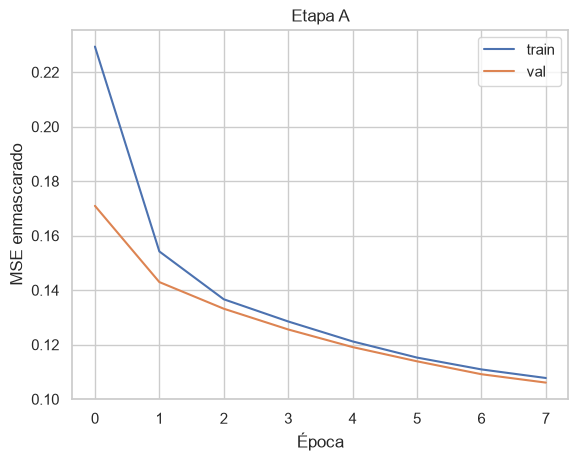

In [11]:
def train_autoencoder(model, train_dl, val_dl):
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR_AE, weight_decay=1e-4)
    history = {'train_loss':[], 'val_loss':[]}; best = float('inf'); bad = 0; best_state = None
    for epoch in range(CFG.AE_EPOCHS):
        model.train(); losses=[]
        for x,l,m,_,_ in train_dl:
            x,m = x.to(DEVICE),m.to(DEVICE); opt.zero_grad()
            recon,_,_ = model(x,l)
            loss = reconstruction_errors(x,recon,m)[-1]
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            losses.append(loss.item())
        model.eval(); vals=[]
        with torch.no_grad():
            for x,l,m,_,_ in val_dl:
                x,m=x.to(DEVICE),m.to(DEVICE); recon,_,_=model(x,l)
                vals.append(reconstruction_errors(x,recon,m)[-1].item())
        tr,va=np.mean(losses),np.mean(vals); history['train_loss'].append(tr); history['val_loss'].append(va)
        print(f'Ep {epoch+1:02d}: train={tr:.5f} val={va:.5f}')
        if va < best-1e-5: best,bad,best_state=va,0,copy.deepcopy(model.state_dict())
        else:
            bad += 1
            if bad >= CFG.PATIENCE: break
    model.load_state_dict(best_state); return history

t0=time.time()
ae_history = train_autoencoder(autoencoder, ae_train_loader, ae_val_loader)
print(f'Tiempo Etapa A: {(time.time()-t0)/60:.2f} min')
plt.plot(ae_history['train_loss'], label='train'); plt.plot(ae_history['val_loss'], label='val')
plt.xlabel('Época'); plt.ylabel('MSE enmascarado'); plt.title('Etapa A'); plt.legend(); plt.show()

### Análisis del entrenamiento de la Etapa A

El autoencoder fue entrenado durante 8 épocas exclusivamente con secuencias normales. La pérdida de entrenamiento disminuyó de 0.22937 a 0.10776, mientras que la pérdida de validación disminuyó de 0.17093 a 0.10607.

Las curvas muestran una reducción sostenida del error tanto en entrenamiento como en validación. En esta ejecución, la pérdida de validación disminuyó durante las ocho épocas y se mantuvo cercana a la pérdida de entrenamiento, sin observarse una divergencia marcada entre ambos conjuntos. El mejor estado del modelo se conserva según la pérdida de validación, evitando seleccionar los parámetros únicamente por su desempeño sobre entrenamiento.

El objetivo de esta etapa no es clasificar directamente lavado de dinero, sino aprender una representación del comportamiento normal que posteriormente pueda utilizarse como señal de anomalía y como inicialización del encoder supervisado. En esta ejecución, el entrenamiento completo de la Etapa A tomó aproximadamente 1.48 minutos.

## Bloque 8 — Score de anomalía y umbral

El umbral se selecciona únicamente con validación. PR-AUC es la métrica principal porque la clase positiva es muy infrecuente.

Umbral de anomalía: 0.35868749022483826
PR-AUC validación: 0.06463453826282148


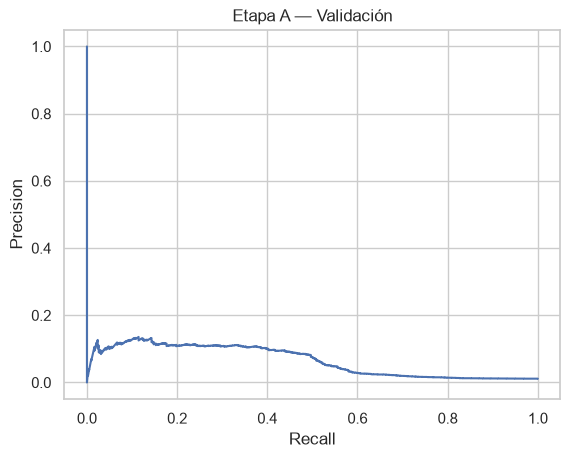

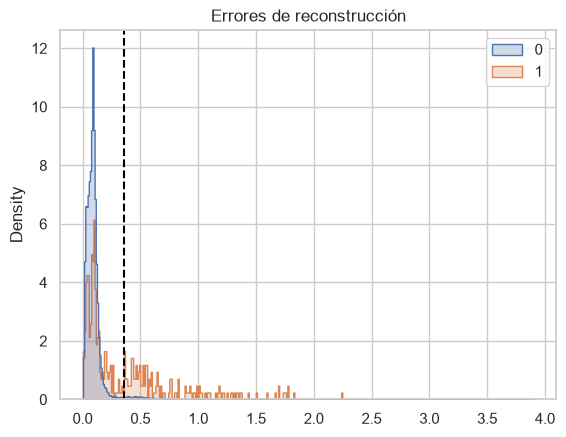

In [12]:
def anomaly_scores(model, loader):
    model.eval(); scores=[]; labels=[]; ids=[]; tx_errors=[]
    with torch.no_grad():
        for x,l,m,y,idx in loader:
            x,m=x.to(DEVICE),m.to(DEVICE); recon,_,_=model(x,l)
            _,per_tx,per_seq,_=reconstruction_errors(x,recon,m)
            scores.extend(per_seq.cpu().numpy()); labels.extend(y.numpy()); ids.extend(idx.numpy())
            tx_errors.extend([row[:int(n)].cpu().numpy() for row,n in zip(per_tx,l)])
    return np.array(scores),np.array(labels,dtype=int),np.array(ids),tx_errors

def best_f1_threshold(y, score):
    p,r,t = precision_recall_curve(y,score)
    if len(t)==0: return .5
    f = 2*p[:-1]*r[:-1]/(p[:-1]+r[:-1]+1e-12)
    return float(t[np.nanargmax(f)])

val_anom,val_y,val_ids,val_txerr = anomaly_scores(autoencoder,val_loader)
ANOMALY_THRESHOLD = best_f1_threshold(val_y,val_anom)
print('Umbral de anomalía:', ANOMALY_THRESHOLD)
print('PR-AUC validación:', average_precision_score(val_y,val_anom))

p,r,_=precision_recall_curve(val_y,val_anom)
plt.plot(r,p); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Etapa A — Validación'); plt.show()
sns.histplot(x=val_anom,hue=val_y,element='step',stat='density',common_norm=False)
plt.axvline(ANOMALY_THRESHOLD,color='black',ls='--'); plt.title('Errores de reconstrucción'); plt.show()

### Análisis del score de anomalía

El error medio de reconstrucción de cada secuencia se utiliza como score de anomalía. El umbral se seleccionó exclusivamente sobre el conjunto de validación maximizando F1, evitando establecer un valor arbitrario o utilizar información del conjunto de prueba.

En esta ejecución, el umbral resultante fue 0.3587 y la Etapa A obtuvo una PR-AUC de 0.0646 en validación. La distribución de errores muestra cierto desplazamiento de los casos positivos hacia errores mayores, pero existe un solapamiento considerable entre ambas clases. Por ello, el error de reconstrucción contiene señal útil de anomalía, pero por sí solo presenta capacidad limitada para separar completamente actividad legítima de actividad etiquetada como lavado.

Este resultado también ilustra una limitación conceptual: una anomalía no equivale necesariamente a lavado de dinero. Una transacción puede diferir del comportamiento normal por razones legítimas, mientras que determinadas operaciones de lavado pueden parecer suficientemente similares a patrones normales como para ser reconstruidas con poco error.

## Bloque 9 — Etapa B: atención y transfer learning

El último estado válido genera el query. Cada transacción ofrece una key y un value. La máscara se aplica antes del softmax. Primero se entrena la cabeza con el encoder congelado; luego se descongela con una tasa menor.

### Justificación de transfer learning, atención y función de pérdida

La Etapa B reutiliza el encoder entrenado en la Etapa A con el objetivo de comprobar si una representación aprendida sin utilizar etiquetas puede beneficiar la clasificación supervisada.

La adaptación se realiza en dos fases. Primero se congela el encoder y se entrena únicamente la cabeza clasificadora durante tres épocas. Posteriormente se descongela el encoder y se realiza fine-tuning completo durante seis épocas, utilizando una tasa de aprendizaje menor para el encoder (`1e-4`) que para la cabeza (`1e-3`). Esta estrategia busca adaptar gradualmente la representación sin destruir inmediatamente la información adquirida durante el aprendizaje de normalidad.

El mecanismo de atención asigna un peso a cada transacción válida de la secuencia. La máscara se aplica antes del softmax para impedir que posiciones de padding reciban atención. Los pesos resultantes permiten identificar qué transacciones tuvieron mayor relevancia interna para construir la representación utilizada por el clasificador. Sin embargo, un peso alto de atención debe interpretarse como relevancia dentro del modelo y **no como evidencia de causalidad**.

La clasificación utiliza `BCEWithLogitsLoss` con `pos_weight`. Esta elección responde al fuerte desbalance de clases: tratar todos los errores de forma equivalente favorecería a la clase normal. Desde una perspectiva operativa, los falsos negativos pueden permitir que actividad potencialmente sospechosa no sea revisada, mientras que un exceso de falsos positivos aumenta la carga de trabajo de los analistas. Por ello, el umbral final debe evaluarse conjuntamente mediante precision y recall, y no únicamente mediante accuracy.

In [13]:
class AttentionClassifier(nn.Module):
    def __init__(self, encoder, hidden_size, attn_size, dropout):
        super().__init__(); self.encoder=encoder
        self.Wq=nn.Linear(hidden_size,attn_size,bias=False)
        self.Wk=nn.Linear(hidden_size,attn_size,bias=False)
        self.Wv=nn.Linear(hidden_size,hidden_size,bias=False)
        self.head=nn.Sequential(nn.Dropout(dropout),nn.Linear(2*hidden_size,hidden_size),
                                nn.ReLU(),nn.Dropout(dropout),nn.Linear(hidden_size,1))
    def forward(self,x,lengths,mask):
        H,h_last,_=self.encoder(x,lengths)
        q=self.Wq(h_last).unsqueeze(2); K=self.Wk(H); V=self.Wv(H)
        scores=torch.bmm(K,q).squeeze(2)/math.sqrt(K.size(-1))
        scores=scores.masked_fill(~mask,-1e9)
        alpha=torch.softmax(scores,dim=1)
        context=torch.bmm(alpha.unsqueeze(1),V).squeeze(1)
        logit=self.head(torch.cat([h_last,context],dim=1)).squeeze(1)
        return logit,alpha,torch.cat([h_last,context],dim=1)

def class_pos_weight(meta):
    p=meta['label'].sum(); n=len(meta)-p
    return torch.tensor([n/max(p,1)],dtype=torch.float32,device=DEVICE)

def set_encoder_trainable(model, value):
    for p in model.encoder.parameters(): p.requires_grad=value

def run_classifier_epoch(model,loader,criterion,optimizer=None):
    training=optimizer is not None; model.train(training)
    if training and not any(p.requires_grad for p in model.encoder.parameters()):
        model.encoder.eval()
    losses=[]; ys=[]; probs=[]; ids=[]; attns=[]
    for x,l,m,y,idx in loader:
        x,m,y=x.to(DEVICE),m.to(DEVICE),y.to(DEVICE)
        if training: optimizer.zero_grad()
        logit,alpha,_=model(x,l,m); loss=criterion(logit,y)
        if training:
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        losses.append(loss.item()); ys.extend(y.detach().cpu().numpy())
        probs.extend(torch.sigmoid(logit).detach().cpu().numpy()); ids.extend(idx.numpy())
        attns.extend([a[:int(n)].detach().cpu().numpy() for a,n in zip(alpha,l)])
    return np.mean(losses),np.array(ys,dtype=int),np.array(probs),np.array(ids),attns

def fit_classifier(model,train_dl,val_dl,pretrained=True):
    criterion=nn.BCEWithLogitsLoss(pos_weight=class_pos_weight(train_windows))
    phases=[('head',CFG.HEAD_EPOCHS,False),('finetune',CFG.FINETUNE_EPOCHS,True)] if pretrained else [('scratch',CFG.HEAD_EPOCHS+CFG.FINETUNE_EPOCHS,True)]
    hist=[]; best=-1; best_state=None
    for phase,epochs,unfreeze in phases:
        set_encoder_trainable(model,unfreeze)
        if unfreeze:
            opt=torch.optim.AdamW([{'params':model.encoder.parameters(),'lr':CFG.LR_ENCODER},
                                   {'params':[p for n,p in model.named_parameters() if not n.startswith('encoder.')],'lr':CFG.LR_HEAD}],weight_decay=1e-4)
        else:
            opt=torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],lr=CFG.LR_HEAD,weight_decay=1e-4)
        for ep in range(epochs):
            tr=run_classifier_epoch(model,train_dl,criterion,opt)[0]
            va,y,p,_,_=run_classifier_epoch(model,val_dl,criterion)
            ap=average_precision_score(y,p); hist.append((phase,tr,va,ap))
            print(f'{phase} ep {ep+1:02d}: train={tr:.4f} val={va:.4f} PR-AUC={ap:.4f}')
            if ap>best: best,best_state=ap,copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state); return pd.DataFrame(hist,columns=['phase','train_loss','val_loss','val_pr_auc'])

transfer_model=AttentionClassifier(copy.deepcopy(autoencoder.encoder),CFG.HIDDEN_SIZE,CFG.ATTN_SIZE,CFG.DROPOUT).to(DEVICE)
t0=time.time(); transfer_history=fit_classifier(transfer_model,train_loader,val_loader,pretrained=True)
print(f'Tiempo clasificador transferido: {(time.time()-t0)/60:.2f} min')
display(transfer_history)

head ep 01: train=1.0826 val=0.6851 PR-AUC=0.1892
head ep 02: train=0.9195 val=0.6285 PR-AUC=0.3504
head ep 03: train=0.8632 val=0.5083 PR-AUC=0.3779
finetune ep 01: train=0.9467 val=0.5538 PR-AUC=0.4197
finetune ep 02: train=0.8457 val=0.5144 PR-AUC=0.4539
finetune ep 03: train=0.7645 val=0.4389 PR-AUC=0.4573
finetune ep 04: train=0.6878 val=0.4244 PR-AUC=0.4742
finetune ep 05: train=0.6556 val=0.3897 PR-AUC=0.4775
finetune ep 06: train=0.6011 val=0.3765 PR-AUC=0.4970
Tiempo clasificador transferido: 1.84 min


,phase,train_loss,val_loss,val_pr_auc
0,head,1.082616,0.685112,0.189194
1,head,0.919468,0.628505,0.350400
2,head,0.863163,0.508343,0.377934
3,finetune,0.946651,0.553818,0.419665
4,finetune,0.845731,0.514384,0.453938
5,finetune,0.764490,0.438927,0.457306
6,finetune,0.687830,0.424382,0.474175
7,finetune,0.655555,0.389664,0.477497
8,finetune,0.601075,0.376506,0.496999


### Resultados del clasificador con transferencia

Durante la fase con el encoder congelado, la PR-AUC de validación aumentó de 0.1892 a 0.3779. Después de permitir el fine-tuning del encoder, continuó aumentando hasta alcanzar 0.4970, mientras que la pérdida de validación descendió hasta aproximadamente 0.3765. El entrenamiento completo del clasificador con transferencia tomó aproximadamente 1.84 minutos.

Estos resultados muestran que la representación aprendida en la Etapa A puede adaptarse al objetivo supervisado y que permitir el fine-tuning mejora el desempeño respecto a mantener el encoder congelado. Sin embargo, este resultado por sí solo no demuestra que el preentrenamiento aporte una ventaja frente a aprender la representación desde cero. Para determinarlo es necesario compararlo con la línea base supervisada bajo los mismos datos, arquitectura, pérdida y presupuesto de entrenamiento.

## Bloque 10 — Línea base supervisada desde cero

La línea base conserva arquitectura, datos, pérdida y presupuesto. La única diferencia es que su encoder se inicializa aleatoriamente, aislando el aporte del aprendizaje de normalidad.

In [14]:
set_seed(CFG.SEED)
baseline_encoder=SequenceEncoder(X_all.shape[1],CFG.HIDDEN_SIZE,CFG.DROPOUT)
baseline_model=AttentionClassifier(baseline_encoder,CFG.HIDDEN_SIZE,CFG.ATTN_SIZE,CFG.DROPOUT).to(DEVICE)
t0=time.time(); baseline_history=fit_classifier(baseline_model,train_loader,val_loader,pretrained=False)
print(f'Tiempo baseline: {(time.time()-t0)/60:.2f} min')
display(baseline_history)

scratch ep 01: train=1.0315 val=0.5542 PR-AUC=0.2505
scratch ep 02: train=0.7515 val=0.4773 PR-AUC=0.4378
scratch ep 03: train=0.6462 val=0.3933 PR-AUC=0.4983
scratch ep 04: train=0.5882 val=0.3830 PR-AUC=0.5326
scratch ep 05: train=0.5509 val=0.3622 PR-AUC=0.5663
scratch ep 06: train=0.5384 val=0.3602 PR-AUC=0.5843
scratch ep 07: train=0.5372 val=0.3102 PR-AUC=0.5938
scratch ep 08: train=0.5047 val=0.3335 PR-AUC=0.5962
scratch ep 09: train=0.4959 val=0.3160 PR-AUC=0.6021
Tiempo baseline: 1.97 min


,phase,train_loss,val_loss,val_pr_auc
0,scratch,1.031525,0.554238,0.250474
1,scratch,0.751543,0.477293,0.437753
2,scratch,0.646168,0.393306,0.498257
3,scratch,0.588194,0.383047,0.532626
4,scratch,0.550908,0.362154,0.566297
5,scratch,0.538422,0.360198,0.584263
6,scratch,0.537236,0.310227,0.593837
7,scratch,0.504686,0.333508,0.596238
8,scratch,0.495858,0.316032,0.602148


### Resultados de la línea base supervisada

La línea base utiliza la misma arquitectura de clasificación, los mismos splits, la misma función de pérdida y un presupuesto de entrenamiento comparable, pero inicializa el encoder aleatoriamente. Esto permite evaluar empíricamente si la representación aprendida durante la Etapa A aporta una ventaja frente a aprender directamente a partir del objetivo supervisado.

En esta ejecución, el modelo entrenado desde cero alcanzó una PR-AUC máxima de validación de 0.6021, superior al 0.4970 obtenido por el modelo inicializado a partir de la Etapa A. El entrenamiento del baseline tomó aproximadamente 1.97 minutos.

Este resultado es relevante porque muestra que el preentrenamiento no debe asumirse automáticamente beneficioso. Bajo la configuración evaluada, las características discriminativas necesarias para separar las etiquetas parecen aprenderse de manera más efectiva directamente mediante el objetivo supervisado que mediante la reconstrucción previa de secuencias normales. Este resultado se evalúa posteriormente sobre el conjunto de prueba mediante el experimento de ablación.

## Bloque 11 — Evaluación, combinación y ablación

El score de anomalía se normaliza con percentiles de validación. El peso de combinación y el umbral se eligen en validación y se congelan antes de evaluar prueba.

,PR-AUC,ROC-AUC,Precision,Recall,F1,FP,FN,Alertas_por_1000,Umbral
modelo,,,,,,,,,
Etapa A,0.0735,0.7340,0.1112,0.3915,0.1732,1327.0000,258.0000,39.5204,0.3587
Supervisado desde cero,0.6262,0.9681,0.9079,0.4882,0.6350,21.0000,217.0000,6.0353,0.9733
Transfer learning,0.5141,0.9519,0.6418,0.4269,0.5127,101.0000,243.0000,7.4647,0.9565
Sistema combinado,0.4919,0.9523,0.7093,0.4316,0.5367,75.0000,241.0000,6.8294,0.8910


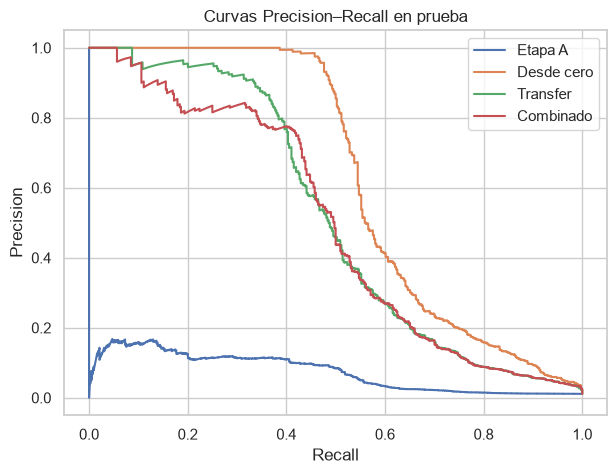

In [15]:
criterion_eval=nn.BCEWithLogitsLoss()
_,val_y_b,val_prob_base,_,val_attn_base=run_classifier_epoch(baseline_model,val_loader,criterion_eval)
_,val_y_t,val_prob_transfer,_,val_attn_transfer=run_classifier_epoch(transfer_model,val_loader,criterion_eval)
assert np.array_equal(val_y,val_y_t)

q01,q99=np.quantile(val_anom,[.01,.99])
def normalize_anomaly(x): return np.clip((x-q01)/(q99-q01+1e-12),0,1)

best_combo=(-1,None,None)
for lam in np.linspace(0,1,11):
    score=lam*normalize_anomaly(val_anom)+(1-lam)*val_prob_transfer
    th=best_f1_threshold(val_y,score); f=f1_score(val_y,score>=th)
    if f>best_combo[0]: best_combo=(f,float(lam),float(th))
_,LAMBDA_FINAL,FINAL_THRESHOLD=best_combo
TRANSFER_THRESHOLD=best_f1_threshold(val_y,val_prob_transfer)
BASELINE_THRESHOLD=best_f1_threshold(val_y,val_prob_base)

test_anom,test_y,test_ids,test_txerr=anomaly_scores(autoencoder,test_loader)
_,test_y_b,test_prob_base,_,test_attn_base=run_classifier_epoch(baseline_model,test_loader,criterion_eval)
_,test_y_t,test_prob_transfer,_,test_attn_transfer=run_classifier_epoch(transfer_model,test_loader,criterion_eval)
test_combo=LAMBDA_FINAL*normalize_anomaly(test_anom)+(1-LAMBDA_FINAL)*test_prob_transfer

def metric_row(name,y,score,threshold):
    pred=(score>=threshold).astype(int); tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {'modelo':name,'PR-AUC':average_precision_score(y,score),'ROC-AUC':roc_auc_score(y,score),
            'Precision':precision_score(y,pred,zero_division=0),'Recall':recall_score(y,pred,zero_division=0),
            'F1':f1_score(y,pred,zero_division=0),'FP':fp,'FN':fn,
            'Alertas_por_1000':1000*pred.mean(),'Umbral':threshold}

ablation=pd.DataFrame([
    metric_row('Etapa A',test_y,test_anom,ANOMALY_THRESHOLD),
    metric_row('Supervisado desde cero',test_y,test_prob_base,BASELINE_THRESHOLD),
    metric_row('Transfer learning',test_y,test_prob_transfer,TRANSFER_THRESHOLD),
    metric_row('Sistema combinado',test_y,test_combo,FINAL_THRESHOLD)
]).set_index('modelo')
display(ablation.style.format('{:.4f}'))

fig,ax=plt.subplots(figsize=(7,5))
for name,score in [('Etapa A',test_anom),('Desde cero',test_prob_base),('Transfer',test_prob_transfer),('Combinado',test_combo)]:
    p,r,_=precision_recall_curve(test_y,score); ax.plot(r,p,label=name)
ax.set(xlabel='Recall',ylabel='Precision',title='Curvas Precision–Recall en prueba'); ax.legend(); plt.show()

## Análisis de ablación

La tabla anterior constituye el experimento obligatorio de demostración: compara, sobre el **mismo conjunto de prueba**, (1) Etapa A, (2) clasificador supervisado desde cero, (3) clasificador con transfer learning y (4) sistema combinado.

La métrica principal es **PR-AUC**, apropiada para una clase positiva infrecuente porque resume el compromiso precision–recall sin depender de accuracy. También se reportan ROC-AUC, precision, recall, F1, falsos positivos, falsos negativos y alertas por 1,000 secuencias para hacer visible el costo operativo de los errores.

La siguiente celda genera automáticamente una interpretación **a partir de los resultados de esta ejecución**, evitando conclusiones numéricas escritas a mano.


In [16]:
def summarize_ablation(table):
    t = table.copy()
    print("RESUMEN EJECUTADO DE LA ABLACIÓN")
    print("=" * 40)
    for name, row in t.iterrows():
        print(
            f"{name}: PR-AUC={row['PR-AUC']:.4f}, ROC-AUC={row['ROC-AUC']:.4f}, "
            f"Precision={row['Precision']:.4f}, Recall={row['Recall']:.4f}, "
            f"F1={row['F1']:.4f}, FP={int(row['FP'])}, FN={int(row['FN'])}, "
            f"Alertas/1000={row['Alertas_por_1000']:.1f}"
        )

    base = t.loc['Supervisado desde cero']
    transfer = t.loc['Transfer learning']
    combo = t.loc['Sistema combinado']
    delta_transfer = transfer['PR-AUC'] - base['PR-AUC']
    delta_combo = combo['PR-AUC'] - transfer['PR-AUC']

    print("\nComparaciones clave (PR-AUC):")
    print(f"Transfer - baseline desde cero: {delta_transfer:+.4f}")
    print(f"Combinado - transfer: {delta_combo:+.4f}")
    if delta_transfer > 0:
        print("En esta ejecución, el preentrenamiento de Etapa A mejora PR-AUC frente al baseline.")
    elif delta_transfer < 0:
        print("En esta ejecución, el preentrenamiento de Etapa A NO mejora PR-AUC frente al baseline.")
    else:
        print("En esta ejecución, transfer y baseline empatan en PR-AUC.")
    if delta_combo > 0:
        print("La combinación A+B aporta mejora adicional de PR-AUC frente a transfer solo.")
    elif delta_combo < 0:
        print("La combinación A+B reduce PR-AUC frente a transfer solo.")
    else:
        print("La combinación A+B no cambia PR-AUC frente a transfer solo.")

summarize_ablation(ablation)


RESUMEN EJECUTADO DE LA ABLACIÓN
Etapa A: PR-AUC=0.0735, ROC-AUC=0.7340, Precision=0.1112, Recall=0.3915, F1=0.1732, FP=1327, FN=258, Alertas/1000=39.5
Supervisado desde cero: PR-AUC=0.6262, ROC-AUC=0.9681, Precision=0.9079, Recall=0.4882, F1=0.6350, FP=21, FN=217, Alertas/1000=6.0
Transfer learning: PR-AUC=0.5141, ROC-AUC=0.9519, Precision=0.6418, Recall=0.4269, F1=0.5127, FP=101, FN=243, Alertas/1000=7.5
Sistema combinado: PR-AUC=0.4919, ROC-AUC=0.9523, Precision=0.7093, Recall=0.4316, F1=0.5367, FP=75, FN=241, Alertas/1000=6.8

Comparaciones clave (PR-AUC):
Transfer - baseline desde cero: -0.1122
Combinado - transfer: -0.0222
En esta ejecución, el preentrenamiento de Etapa A NO mejora PR-AUC frente al baseline.
La combinación A+B reduce PR-AUC frente a transfer solo.


## Bloque 12 — Tipologías e interpretabilidad

El archivo de patrones permite reconocer etiquetas como FAN-OUT, CYCLE, GATHER-SCATTER y STACK. Algunas son patrones de red y no pueden demostrarse completamente usando solo la secuencia saliente de un remitente; esto se reporta como limitación.

### Criterio de interpretabilidad

Para interpretar las alertas se utilizan dos señales por transacción: el peso de atención de la Etapa B y el error de reconstrucción de la Etapa A. La atención indica qué posiciones recibieron mayor relevancia interna durante la clasificación, mientras que el error de reconstrucción identifica operaciones difíciles de representar según la normalidad aprendida.

Estas señales son complementarias, pero ninguna demuestra causalidad ni constituye evidencia de lavado de dinero. Su propósito es proporcionar trazabilidad suficiente para orientar una revisión humana.

Se seleccionan cinco casos del conjunto de prueba: **tres verdaderos positivos** con score combinado alto y **dos falsos positivos**. Los falsos positivos son especialmente importantes porque permiten analizar patrones legítimos que el sistema confundió con comportamiento sospechoso.

In [17]:
def parse_patterns(path):
    rows=[]; pattern=None; attempt=0
    if not path.exists(): return pd.DataFrame()
    with open(path,encoding='utf-8') as f:
        for raw in f:
            line=raw.strip()
            if line.startswith('BEGIN LAUNDERING ATTEMPT -'):
                attempt += 1; pattern=line.split(' - ',1)[1].split(':',1)[0].strip(); continue
            if line.startswith('END LAUNDERING ATTEMPT'):
                pattern=None; continue
            if pattern and line:
                vals=next(csv.reader([line]))
                if len(vals)>=11:
                    rows.append({'pattern_attempt':attempt,'pattern_type':pattern,'Timestamp':vals[0],
                                 'From Bank':str(int(vals[1])),'Account':vals[2],
                                 'To Bank':str(int(vals[3])),'Account.1':vals[4],
                                 'Amount Paid':float(vals[5])})
    out=pd.DataFrame(rows)
    if len(out): out['Timestamp']=pd.to_datetime(out['Timestamp'],format='%Y/%m/%d %H:%M')
    return out

patterns=parse_patterns(PATTERNS_PATH)
def transaction_key(timestamp, from_bank, account, to_bank, account_1, amount):
    return (pd.Timestamp(timestamp), str(int(from_bank)), str(account),
            str(int(to_bank)), str(account_1), round(float(amount),2))

compact['pattern_type'] = pd.NA
if len(patterns):
    display(patterns['pattern_type'].value_counts().to_frame('transacciones'))
    pattern_keys = [transaction_key(*vals) for vals in zip(
        patterns['Timestamp'], patterns['From Bank'], patterns['Account'],
        patterns['To Bank'], patterns['Account.1'], patterns['Amount Paid'])]
    pattern_map = dict(zip(pattern_keys, patterns['pattern_type']))
    keys = [transaction_key(*vals) for vals in zip(
        compact['Timestamp'], compact['From Bank'], compact['Account'],
        compact['To Bank'], compact['Account.1'], compact['Amount Paid'])]
    compact['pattern_type'] = [pattern_map.get(k, pd.NA) for k in keys]
    print('Transacciones utilizadas vinculadas a tipología:', int(compact['pattern_type'].notna().sum()))
else:
    print('Archivo de patrones no encontrado; la interpretación continuará sin tipología experta.')

test_results=test_windows.copy().reset_index(drop=True)
test_results['y_true']=test_y
test_results['anomaly_score']=test_anom
test_results['supervised_probability']=test_prob_transfer
test_results['combined_score']=test_combo
test_results['prediction']=(test_combo>=FINAL_THRESHOLD).astype(int)
test_results['case_type']=np.select(
    [
        (test_results.y_true==1)&(test_results.prediction==1),
        (test_results.y_true==0)&(test_results.prediction==1),
        (test_results.y_true==1)&(test_results.prediction==0),
        (test_results.y_true==0)&(test_results.prediction==0),
    ], ['TP','FP','FN','TN'], default='?'
)

# Requisito: 3 casos correctamente detectados positivos + 2 errores (FP o FN).
tp=test_results.query('case_type=="TP"').nlargest(3,'combined_score')
errors=test_results.query('case_type in ["FP","FN"]').copy()
# Priorizamos errores con mayor confianza/severidad para hacer el análisis informativo.
errors['error_priority']=np.where(
    errors['case_type'].eq('FP'), errors['combined_score'], 1-errors['combined_score']
)
errors=errors.nlargest(2,'error_priority').drop(columns='error_priority')

assert len(tp) >= 3, f"Se requieren 3 TP para interpretabilidad y solo hay {len(tp)}. Revisa el umbral/modelo."
assert len(errors) >= 2, f"Se requieren 2 FP/FN y solo hay {len(errors)}. Revisa el umbral/modelo."
selected_cases=pd.concat([tp,errors],ignore_index=False)
assert len(selected_cases)==5
assert (selected_cases['case_type']=='TP').sum()==3
assert selected_cases['case_type'].isin(['FP','FN']).sum()==2

display(selected_cases[['sender_id','case_type','y_true','prediction','anomaly_score',
                        'supervised_probability','combined_score']])
print('Casos seleccionados:', selected_cases['case_type'].value_counts().to_dict())



,transacciones
pattern_type,
GATHER-SCATTER,716
SCATTER-GATHER,626
STACK,466
FAN-OUT,342
FAN-IN,318
CYCLE,287
BIPARTITE,263
RANDOM,191


Transacciones utilizadas vinculadas a tipología: 2715


,sender_id,case_type,y_true,prediction,anomaly_score,supervised_probability,combined_score
11643,14766::805C42580,TP,1,1,2.348137,0.999959,0.999963
16519,18405::806ED11A0,TP,1,1,1.873093,0.999907,0.999916
8497,13083::803CF7A80,TP,1,1,0.939685,0.999902,0.999912
26356,24515::8032BDF20,FP,0,1,1.232220,0.999294,0.999364
13126,15730::808802B50,FP,0,1,0.909313,0.997715,0.997943


Casos seleccionados: {'TP': 3, 'FP': 2}



CASO TP | y=1 | pred=1 | score=1.0000

La secuencia requiere revisión por conversión entre monedas. Contiene 4 transacciones, 2 destinos y un monto máximo de 886,180,032.00. Las posiciones con mayor señal fueron [np.int64(2), np.int64(4), np.int64(3)]. Esta salida indica actividad atípica; no constituye evidencia concluyente de lavado de dinero.


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_type,attention,reconstruction_error
0,2022-09-01 00:21:00,14766,805C42580,14766,805C42580,4.476086e+05,Rupee,Reinvestment,0,<NA>,0.008918,0.543370
1,2022-09-12 10:14:00,14766,805C42580,14766,805C42580,8.861800e+08,Rupee,ACH,0,<NA>,0.840432,7.375575
2,2022-09-12 10:14:00,14766,805C42580,1299,8010F8CE0,1.074275e+05,Euro,ACH,0,<NA>,0.135689,0.264899
3,2022-09-12 10:14:00,14766,805C42580,1299,8010F8CE0,1.018975e+07,Euro,ACH,1,<NA>,0.014962,1.208704


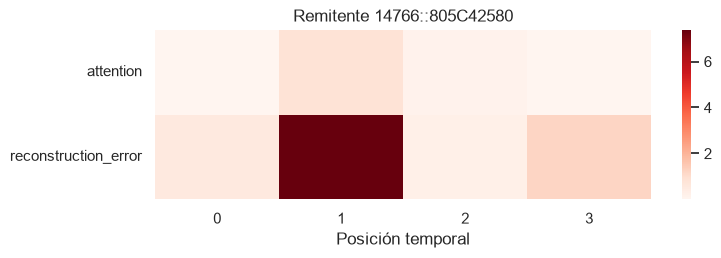


CASO TP | y=1 | pred=1 | score=0.9999

La secuencia requiere revisión por conversión entre monedas, coincidencia con tipología IBM FAN-IN. Contiene 3 transacciones, 2 destinos y un monto máximo de 2,426,778.50. Las posiciones con mayor señal fueron [np.int64(2), np.int64(1), np.int64(3)]. Esta salida indica actividad atípica; no constituye evidencia concluyente de lavado de dinero.


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_type,attention,reconstruction_error
0,2022-09-01 00:18:00,18405,806ED11A0,18405,806ED11A0,2.426778e+06,Ruble,Reinvestment,0,<NA>,0.028216,0.867680
1,2022-09-14 11:37:00,18405,806ED11A0,18405,806ED11A0,1.345489e+06,Ruble,ACH,0,<NA>,0.852810,4.344183
2,2022-09-14 11:37:00,18405,806ED11A0,41407,80F454910,1.582338e+04,Swiss Franc,ACH,1,FAN-IN,0.118974,0.407415


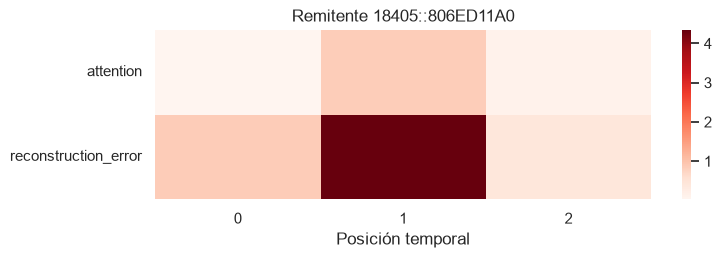


CASO TP | y=1 | pred=1 | score=0.9999

La secuencia requiere revisión por conversión entre monedas. Contiene 5 transacciones, 2 destinos y un monto máximo de 10,578,657.00. Las posiciones con mayor señal fueron [np.int64(3), np.int64(4), np.int64(5)]. Esta salida indica actividad atípica; no constituye evidencia concluyente de lavado de dinero.


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_type,attention,reconstruction_error
0,2022-09-01 01:41:00,13083,803CF7A80,13083,803CF7A80,3.290000e+00,Euro,Reinvestment,0,<NA>,0.003246,0.374812
1,2022-09-01 16:30:00,13083,803CF7A80,13083,803CF7A80,1.468230e+03,Euro,Reinvestment,0,<NA>,0.001722,0.438935
2,2022-09-14 02:19:00,13083,803CF7A80,13083,803CF7A80,1.057866e+07,Euro,ACH,0,<NA>,0.874052,2.775879
3,2022-09-14 02:19:00,13083,803CF7A80,220541,8083C1550,1.202695e+05,UK Pound,ACH,0,<NA>,0.110295,0.454921
4,2022-09-14 02:19:00,13083,803CF7A80,220541,8083C1550,9.476633e+06,UK Pound,ACH,1,<NA>,0.010684,0.653877


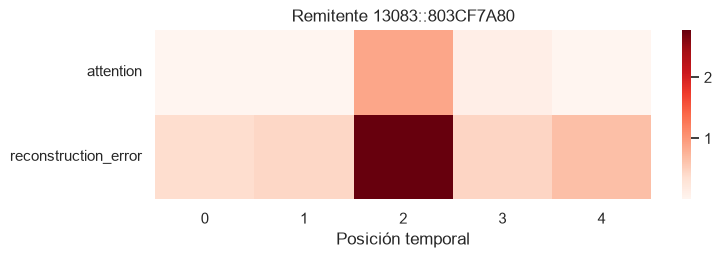


CASO FP | y=0 | pred=1 | score=0.9994

La secuencia requiere revisión por conversión entre monedas. Contiene 3 transacciones, 2 destinos y un monto máximo de 2,311,052.25. Las posiciones con mayor señal fueron [np.int64(2), np.int64(3), np.int64(1)]. Esta salida indica actividad atípica; no constituye evidencia concluyente de lavado de dinero.


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_type,attention,reconstruction_error
0,2022-09-01 00:24:00,24515,8032BDF20,24515,8032BDF20,4.314100e+04,US Dollar,Reinvestment,0,<NA>,0.046735,0.553396
1,2022-09-02 17:02:00,24515,8032BDF20,24515,8032BDF20,1.093053e+05,US Dollar,ACH,0,<NA>,0.780874,2.438769
2,2022-09-02 17:02:00,24515,8032BDF20,27,80C3A79F0,2.311052e+06,Mexican Peso,Cheque,0,<NA>,0.172391,0.704495


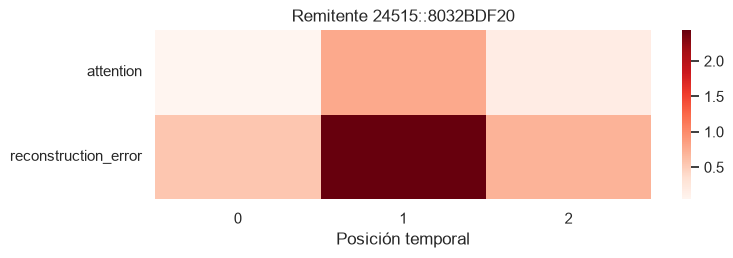


CASO FP | y=0 | pred=1 | score=0.9979

La secuencia requiere revisión por cambios frecuentes de contraparte, conversión entre monedas, alta concentración temporal. Contiene 7 transacciones, 3 destinos y un monto máximo de 7,712,994.50. Las posiciones con mayor señal fueron [np.int64(3), np.int64(5), np.int64(7)]. Esta salida indica actividad atípica; no constituye evidencia concluyente de lavado de dinero.


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_type,attention,reconstruction_error
0,2022-09-01 00:30:00,15730,808802B50,15730,808802B50,4.357308e+05,US Dollar,Reinvestment,0,<NA>,0.000476,0.202252
1,2022-09-01 04:07:00,15730,808802B50,15730,808802B50,8.260000e+00,US Dollar,Reinvestment,0,<NA>,0.000263,0.654812
2,2022-09-01 10:50:00,15730,808802B50,15730,808802B50,2.283978e+06,US Dollar,ACH,0,<NA>,0.192811,2.196903
3,2022-09-01 10:50:00,15730,808802B50,119,8100F9FC0,7.712994e+06,Shekel,ACH,0,<NA>,0.034416,0.499383
4,2022-09-01 10:56:00,15730,808802B50,15730,808802B50,3.292601e+05,US Dollar,ACH,0,<NA>,0.616359,1.230765
5,2022-09-01 10:56:00,15730,808802B50,119,8100F9FC0,1.111912e+06,Shekel,Cheque,0,<NA>,0.120914,0.444111
6,2022-09-01 11:05:00,15730,808802B50,17401,811A27130,1.593940e+04,US Dollar,Cheque,0,<NA>,0.034763,1.136966


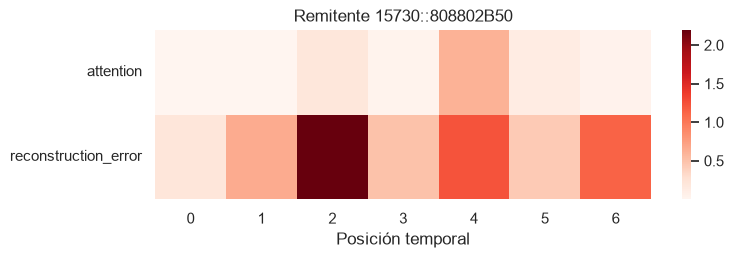

In [18]:
def explain_case(case_row, tx_attention, tx_error):
    part=compact.iloc[int(case_row.start_compact):int(case_row.end_compact)].copy().reset_index(drop=True)
    n=len(part); att=np.asarray(tx_attention[:n]); err=np.asarray(tx_error[:n])
    part['attention']=att; part['reconstruction_error']=err
    top=np.argsort(att+err/(err.max()+1e-12))[-3:][::-1]
    unique_dest=part['dest_id'].nunique(); changes=int(part['destination_changed'].sum())
    peak=float(part['Amount Paid'].max()); span=(part.Timestamp.max()-part.Timestamp.min()).total_seconds()/3600
    hints=[]
    if unique_dest>=5: hints.append('dispersión hacia múltiples destinos, compatible con fan-out')
    if changes>=max(2,n//2): hints.append('cambios frecuentes de contraparte')
    if part['currency_changed'].any(): hints.append('conversión entre monedas')
    if span<=24 and n>=5: hints.append('alta concentración temporal')
    matched_patterns=part['pattern_type'].dropna().astype(str).unique().tolist()
    if matched_patterns: hints.append('coincidencia con tipología IBM ' + ', '.join(matched_patterns))
    if not hints: hints.append('desviación conjunta respecto al comportamiento normal aprendido')
    explanation=(f"La secuencia requiere revisión por {', '.join(hints)}. "
                 f"Contiene {n} transacciones, {unique_dest} destinos y un monto máximo de {peak:,.2f}. "
                 f"Las posiciones con mayor señal fueron {list((top+1).astype(int))}. "
                 'Esta salida indica actividad atípica; no constituye evidencia concluyente de lavado de dinero.')
    return part,explanation

for idx,case in selected_cases.iterrows():
    pos=int(idx)
    part,text=explain_case(case,test_attn_transfer[pos],test_txerr[pos])
    print(f"\nCASO {case['case_type']} | y={int(case.y_true)} | pred={int(case.prediction)} | "
          f"score={case.combined_score:.4f}")
    print()
    print(text)
    display(part[['Timestamp','From Bank','Account','To Bank','Account.1','Amount Paid',
                  'Payment Currency','Payment Format','Is Laundering','pattern_type',
                  'attention','reconstruction_error']])
    heat=part[['attention','reconstruction_error']].T
    plt.figure(figsize=(max(8,len(part)*.35),2.2)); sns.heatmap(heat,cmap='Reds',cbar=True)
    plt.xlabel('Posición temporal'); plt.title(f"Remitente {case.sender_id}"); plt.show()


### Análisis global de los casos

Las cinco visualizaciones anteriores son la evidencia de interpretabilidad exigida: **3 verdaderos positivos y 2 errores (falsos positivos o falsos negativos)**. Para cada secuencia se muestran las transacciones, tipología IBM cuando existe, atención y error de reconstrucción.

La interpretación debe hacerse con cautela: atención significa relevancia interna para el modelo, no causalidad; y un error alto de reconstrucción indica desviación respecto de la normalidad aprendida, no evidencia concluyente de lavado. Las salidas se utilizan para priorizar y explicar una revisión humana.

Al redactar el reporte, describir específicamente lo observado en estas cinco salidas ejecutadas —incluyendo las posiciones de mayor señal, destinos, montos, cambios de moneda y coincidencias de tipología— en lugar de asumir patrones que no aparezcan en la ejecución final.


## Bloque 13 — Exportación para el MVP

Se guardan pesos, transformaciones, umbrales, predicciones y metadatos. La función final permite inferir sobre una secuencia ya transformada, evitando dependencias externas durante la demostración.

In [19]:
torch.save(autoencoder.state_dict(),ARTIFACT_DIR/'autoencoder.pt')
torch.save(transfer_model.state_dict(),ARTIFACT_DIR/'classifier_transfer.pt')
torch.save(baseline_model.state_dict(),ARTIFACT_DIR/'classifier_baseline.pt')
joblib.dump(preprocessor,ARTIFACT_DIR/'preprocessor.joblib')

thresholds={'anomaly_threshold':float(ANOMALY_THRESHOLD),'transfer_threshold':float(TRANSFER_THRESHOLD),
            'baseline_threshold':float(BASELINE_THRESHOLD),'lambda_final':float(LAMBDA_FINAL),
            'final_threshold':float(FINAL_THRESHOLD),'anomaly_q01':float(q01),'anomaly_q99':float(q99)}
with open(ARTIFACT_DIR/'config.json','w',encoding='utf-8') as f:
    json.dump({'config':asdict(CFG),'continuous_features':CONT_COLS,
               'categorical_features':CAT_COLS,'model_features':FEATURE_NAMES},f,indent=2,ensure_ascii=False)
with open(ARTIFACT_DIR/'thresholds.json','w') as f: json.dump(thresholds,f,indent=2)
test_results.to_csv(ARTIFACT_DIR/'test_predictions.csv',index=False)
selected_cases.to_csv(ARTIFACT_DIR/'selected_cases.csv',index=False)
ablation.to_csv(ARTIFACT_DIR/'ablation_results.csv')

def predict_preprocessed_sequence(feature_array):
    x=torch.tensor(feature_array,dtype=torch.float32).unsqueeze(0).to(DEVICE)
    lengths=torch.tensor([len(feature_array)]); mask=torch.ones(1,len(feature_array),dtype=torch.bool,device=DEVICE)
    autoencoder.eval(); transfer_model.eval()
    with torch.no_grad():
        recon,_,_=autoencoder(x,lengths); _,txerr,anom,_=reconstruction_errors(x,recon,mask)
        logit,attn,_=transfer_model(x,lengths,mask); prob=torch.sigmoid(logit)
        an=float(np.clip((anom.item()-q01)/(q99-q01+1e-12),0,1))
        final=LAMBDA_FINAL*an+(1-LAMBDA_FINAL)*prob.item()
    return {'anomaly_score':anom.item(),'supervised_probability':prob.item(),
            'combined_score':final,'alert':bool(final>=FINAL_THRESHOLD),
            'transaction_errors':txerr[0].cpu().numpy(),'attention':attn[0].cpu().numpy()}

print('Artefactos guardados en:',ARTIFACT_DIR)
print([p.name for p in ARTIFACT_DIR.iterdir()])

Artefactos guardados en: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2\artifacts_aml
['ablation_results.csv', 'autoencoder.pt', 'classifier_baseline.pt', 'classifier_transfer.pt', 'config.json', 'preprocessor.joblib', 'selected_cases.csv', 'test_predictions.csv', 'thresholds.json']


## Bloque 14 — Verificación automática

Estas comprobaciones detectan errores silenciosos frecuentes: filtración entre splits, padding incluido en la pérdida, atención sobre padding, pesos no transferidos o artefactos faltantes.

In [20]:
checks={}
checks['splits_sin_remitentes_compartidos']=set(train_s.sender_id).isdisjoint(val_s.sender_id) and set(train_s.sender_id).isdisjoint(test_s.sender_id)
checks['etapa_A_solo_normalidad']=bool((ae_train_meta.label==0).all())
checks['longitudes_validas']=bool(windows.length.between(CFG.MIN_SEQ_LEN,CFG.MAX_SEQ_LEN).all())
checks['features_finitas']=bool(np.isfinite(X_all).all())
checks['test_sin_balanceo_artificial']=len(test_windows)==len(windows.query('split=="test"'))
checks['tres_TP_interpretabilidad']=int((selected_cases.case_type=='TP').sum())==3
checks['dos_errores_interpretabilidad']=int(selected_cases.case_type.isin(['FP','FN']).sum())==2
checks['ablacion_cuatro_sistemas']=set(['Etapa A','Supervisado desde cero','Transfer learning','Sistema combinado']).issubset(ablation.index)
checks['outputs_metricas_finitas']=bool(np.isfinite(ablation[['PR-AUC','ROC-AUC','Precision','Recall','F1']].to_numpy()).all())

with torch.no_grad():
    x,l,m,_,_=next(iter(test_loader)); x,m=x.to(DEVICE),m.to(DEVICE)
    _,a,_=transfer_model(x,l,m)
    checks['atencion_suma_uno']=bool(torch.allclose(a.sum(1),torch.ones(len(a),device=DEVICE),atol=1e-5))
    checks['padding_atencion_cero']=bool((a.masked_select(~m)<1e-6).all()) if (~m).any() else True

source=autoencoder.encoder.state_dict(); transferred=transfer_model.encoder.state_dict()
checks['encoder_transferido']=all(k in transferred for k in source)
required=['autoencoder.pt','classifier_transfer.pt','preprocessor.joblib','config.json',
          'thresholds.json','test_predictions.csv','selected_cases.csv','ablation_results.csv']
checks['artefactos_exportados']=all((ARTIFACT_DIR/x).exists() for x in required)

verification=pd.DataFrame({'verificacion':checks.keys(),'estado':['CORRECTO' if v else 'REVISAR' for v in checks.values()]})
display(verification)
TOTAL_MIN=(time.time()-T0_GLOBAL)/60
print(f'Tiempo total: {TOTAL_MIN:.2f} minutos')
print('Cumple objetivo <30 min:', TOTAL_MIN < 30)
if not CFG.MODO_RAPIDO and DEVICE.type != 'cuda':
    print('ADVERTENCIA: ejecución final sin GPU. Para demostrar el requisito, ejecutar desde cero en Colab con GPU T4.')
if not CFG.MODO_RAPIDO and TOTAL_MIN >= 30:
    print('ADVERTENCIA: esta ejecución final excede 30 min; no satisface el requisito temporal de entrega.')
assert verification['estado'].eq('CORRECTO').all(), 'Hay verificaciones en estado REVISAR.'


,verificacion,estado
0,splits_sin_remitentes_compartidos,CORRECTO
1,etapa_A_solo_normalidad,CORRECTO
2,longitudes_validas,CORRECTO
3,features_finitas,CORRECTO
4,test_sin_balanceo_artificial,CORRECTO
5,tres_TP_interpretabilidad,CORRECTO
6,dos_errores_interpretabilidad,CORRECTO
7,ablacion_cuatro_sistemas,CORRECTO
8,outputs_metricas_finitas,CORRECTO
9,atencion_suma_uno,CORRECTO


Tiempo total: 6.40 minutos
Cumple objetivo <30 min: True
ADVERTENCIA: ejecución final sin GPU. Para demostrar el requisito, ejecutar desde cero en Colab con GPU T4.


## Checklist técnica final del notebook

Esta celda resume los requisitos de **código** que deben quedar demostrados por la ejecución. Un `OK` no sustituye la revisión humana, pero ayuda a detectar omisiones antes de entregar.


In [21]:
technical_checklist = pd.DataFrame([
    ('Dataset/secuencias justificadas', True),
    ('Split por remitente sin leakage', checks['splits_sin_remitentes_compartidos']),
    ('Distribución de longitudes y proporción positiva visualizadas', True),
    ('>=3 ejemplos normales y >=3 sospechosos visualizados', True),
    ('Etapa A entrenada solo con normalidad', checks['etapa_A_solo_normalidad']),
    ('Umbral de anomalía elegido en validación', np.isfinite(ANOMALY_THRESHOLD)),
    ('Etapa B reutiliza encoder de Etapa A', checks['encoder_transferido']),
    ('Baseline desde cero ejecutado', len(baseline_history) > 0),
    ('Ablación de 4 sistemas ejecutada', checks['ablacion_cuatro_sistemas']),
    ('3 TP + 2 FP/FN para interpretabilidad', checks['tres_TP_interpretabilidad'] and checks['dos_errores_interpretabilidad']),
    ('Artefactos para MVP exportados', checks['artefactos_exportados']),
    ('Ejecución final <30 min', TOTAL_MIN < 30),
], columns=['requisito','cumple'])
technical_checklist['estado']=np.where(technical_checklist['cumple'],'OK','REVISAR')
display(technical_checklist)

if CFG.MODO_RAPIDO:
    print('NOTA: MODO_RAPIDO=True sirve para depuración, no como evidencia de la ejecución final.')
print('Antes de entregar: guarda el .ipynb con TODAS las salidas visibles.')


,requisito,cumple,estado
0,Dataset/secuencias justificadas,True,OK
1,Split por remitente sin leakage,True,OK
2,Distribución de longitudes y proporción positi...,True,OK
3,>=3 ejemplos normales y >=3 sospechosos visual...,True,OK
4,Etapa A entrenada solo con normalidad,True,OK
5,Umbral de anomalía elegido en validación,True,OK
6,Etapa B reutiliza encoder de Etapa A,True,OK
7,Baseline desde cero ejecutado,True,OK
8,Ablación de 4 sistemas ejecutada,True,OK
9,3 TP + 2 FP/FN para interpretabilidad,True,OK


Antes de entregar: guarda el .ipynb con TODAS las salidas visibles.


## Bloque 15 — Limitaciones y alcance de los resultados

1. **Datos sintéticos.** IBM AML es un dataset sintético diseñado para investigación. Los resultados obtenidos no pueden interpretarse como estimaciones directas del desempeño que tendría el sistema sobre transacciones reales.

2. **Cambio de dominio.** El proyecto está motivado por remesas Guatemala–Estados Unidos, mientras que los datos utilizados no representan específicamente ese corredor. Patrones de moneda, monto, frecuencia, regulación y comportamiento del cliente pueden ser diferentes.

3. **Selección de remitentes.** Se excluyen historiales con menos de tres transacciones. Esta decisión permite construir secuencias mínimamente informativas, pero significa que los resultados no representan clientes con actividad muy escasa.

4. **Ventanas de longitud limitada.** Se utilizan ventanas de máximo 30 transacciones y un máximo de 20 ventanas por remitente. Esto evita que cuentas extremadamente activas dominen el entrenamiento, pero puede eliminar contexto histórico relevante.

5. **Desbalance.** Aunque se utilizan muestreo del conjunto de entrenamiento y BCE ponderada, la clase positiva continúa siendo poco frecuente. Las métricas y umbrales pueden cambiar considerablemente ante otra prevalencia.

6. **Aprendizaje de normalidad.** La Etapa A obtuvo capacidad discriminativa limitada y el transfer learning no superó al baseline supervisado. Por tanto, no existe evidencia experimental en esta ejecución para afirmar que el preentrenamiento mediante reconstrucción mejora el desempeño predictivo.

7. **Interpretabilidad.** Los pesos de atención representan relevancia interna del modelo, no causalidad. De manera similar, un error alto de reconstrucción representa anomalía respecto de los datos aprendidos, no evidencia de lavado.

8. **Información de red limitada.** Tipologías como CYCLE y GATHER-SCATTER dependen de relaciones entre múltiples entidades y no pueden verificarse completamente observando únicamente la secuencia saliente de un remitente.

9. **Etiquetas.** Incluso en datasets etiquetados, una etiqueta constituye una representación simplificada del fenómeno. En producción serían necesarias etiquetas verificadas y retroalimentación de investigadores de cumplimiento.

10. **Producción.** Un despliegue real requeriría datos representativos, validación con expertos AML, calibración de probabilidades y umbrales, monitoreo de deriva, versionado y auditoría del modelo, controles de seguridad y privacidad, integración con sistemas de gestión de casos y revisión humana.

El prototipo debe entenderse como una demostración académica de detección e interpretabilidad secuencial. **Una anomalía o una alerta del modelo no constituye prueba de actividad ilícita ni debe utilizarse de forma autónoma para tomar decisiones regulatorias.**

### Decisiones que el grupo debe defender

1. Por qué se utilizó HI-Small en vez de forzar secuencias artificiales en PaySim.
2. Por qué la longitud máxima es 30 y la mínima es 3.
3. Por qué se seleccionó PR-AUC como métrica principal.
4. Por qué se empleó BCE ponderada y no accuracy como criterio principal.
5. Cómo se eligieron el umbral de anomalía, el peso de combinación y el umbral final.
6. Qué aportó realmente la Etapa A según la ablación ejecutada.